# Grid styling

Every chart uses exactly one *total* style — fully specified over the factory template, ambient rcParams never leak in. The default is the shipped `mplchart` style, whose whole opinion is two grid keys: `axes.grid: True`, `grid.alpha: 0.4`. A style that doesn't set them gets a bare (gridless) chart — the two settings to be aware of. The canvas reads the effective rc: root draws the x-grid, panes their y-grid, iff `axes.grid` (and `axes.grid.axis`) say so.

In [1]:
from mplchart.chart import Chart
from mplchart.indicators import MACD, RSI, SMA
from mplchart.primitives import Candlesticks, LinePlot, Pane, Volume
from mplchart.samples import sample_prices

prices = sample_prices()
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [2]:
def show_grid(prices, title, style=None):
    """Plot a full chart under a style — grid control is just rc keys."""
    (Chart(prices, title=title, max_bars=250, style=style)
        .plot(
            Candlesticks(), Volume(), SMA(50), SMA(200),
            Pane("above", yticks=(30, 50, 70)),
            LinePlot(RSI(), overbought=70, oversold=30),
            Pane("below"),
            MACD(),
        )
        .show()
    )

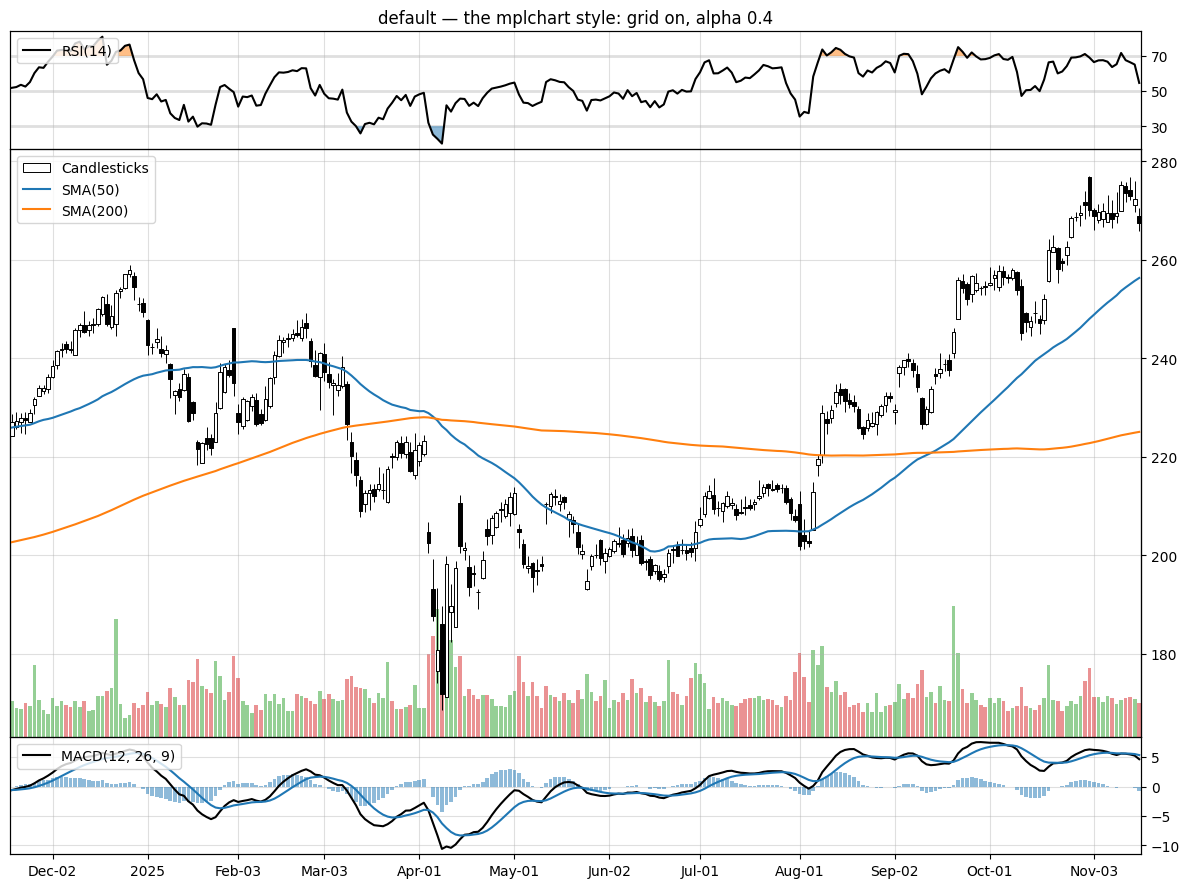

In [3]:
show_grid(prices, "default — the mplchart style: grid on, alpha 0.4")

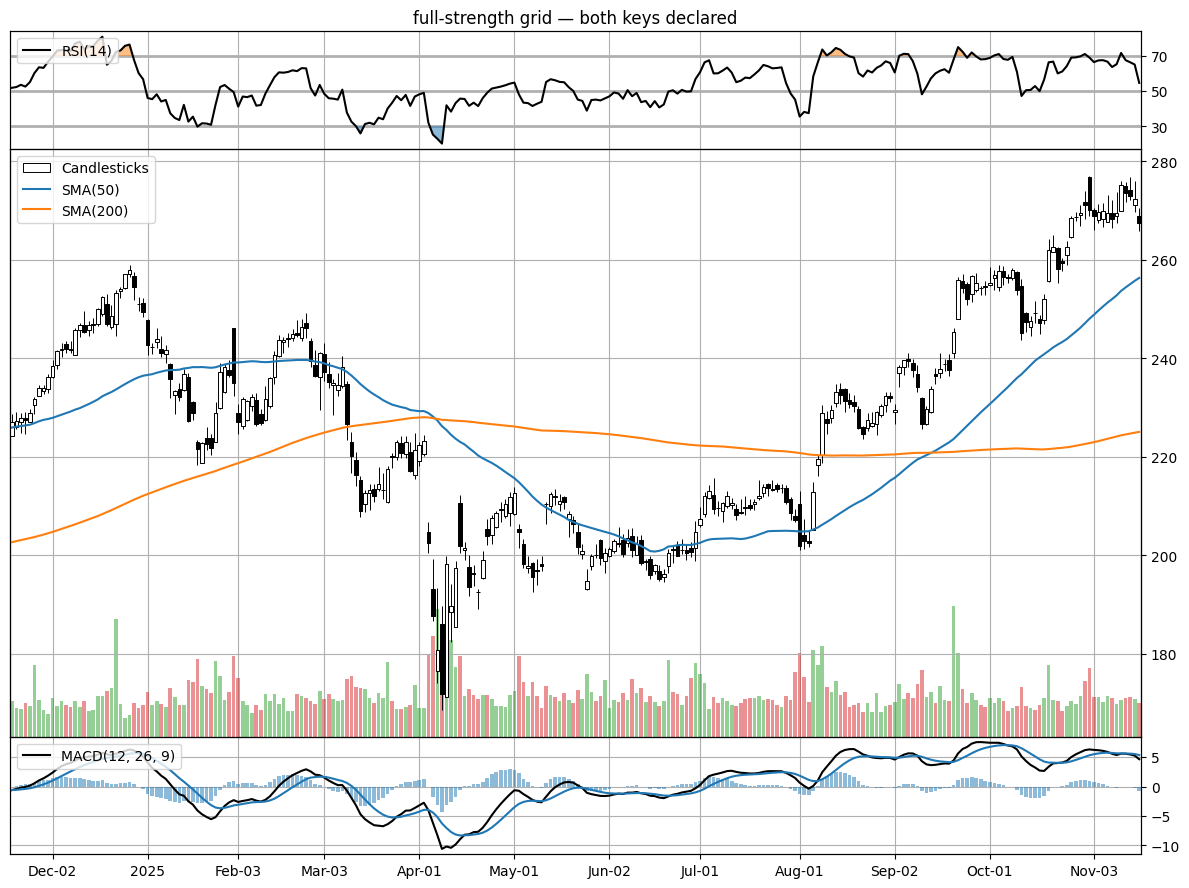

In [4]:
show_grid(prices, "full-strength grid — both keys declared",
          style={"rc": {"axes.grid": True, "grid.alpha": 1.0}})

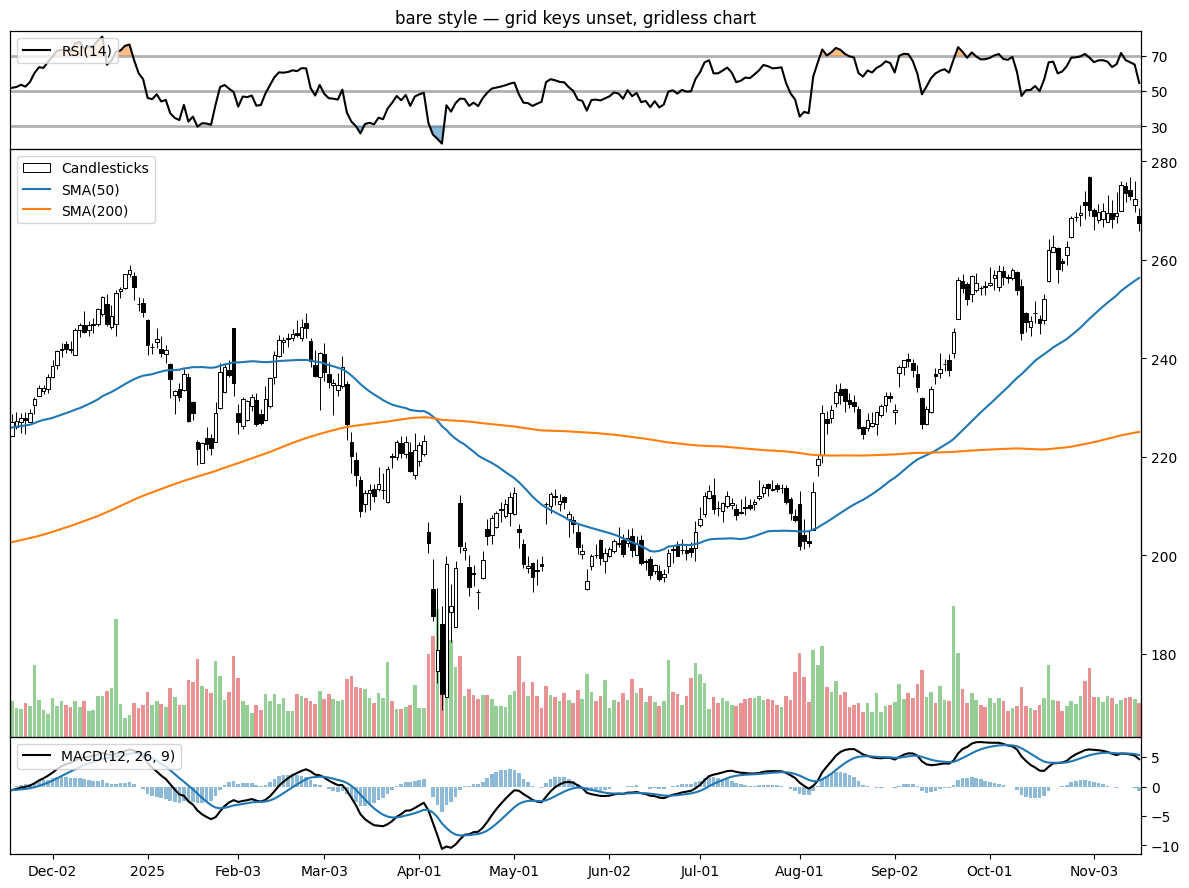

In [5]:
show_grid(prices, "bare style — grid keys unset, gridless chart",
          style={"rc": {}})